In [ ]:


class RadialGaussianConv2d(torch.nn.Module):
    """
    2D convolution with a radially symmetric kernel parameterized as a
    linear combination of Gaussian rings.

    Kernel(x, y) = sum_j coeff[out, in, j] * exp(-(r - rings[j])^2 / (2*sigma[j]^2)),
    where r = sqrt(x^2 + y^2) on the kernel grid.

    Simplified: stride=1, padding=0 (valid), groups=1, dilation=1, bias=None.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        rings: Sequence[float],
        sigma: Union[float, Sequence[float]],
    ):
        super().__init__()
        if isinstance(sigma, (int, float)):
            sigma = [float(sigma)] * len(rings)
        assert len(rings) == len(sigma) and len(rings) > 0, "rings and sigma must match and be non-empty"
        for r in rings:
            assert r >= 0.0
        for s in sigma:
            assert s > 0.0


        self.in_channels = int(in_channels)
        self.out_channels = int(out_channels)
        self.kernel_size = int(kernel_size)
        self.padding = (self.kernel_size - 1) // 2

        # Learnable ring coefficients: (out, in, R)
        R = len(rings)
        self.coeff = torch.nn.Parameter(torch.zeros(out_channels, in_channels, R))

        # Fixed ring parameters (buffers)
        self.register_buffer("rings", torch.tensor(rings, dtype=torch.get_default_dtype()))   # (R,)
        self.register_buffer("sigma", torch.tensor(sigma, dtype=torch.get_default_dtype()))   # (R,)

        # Pre-sample the radial basis on the kernel grid: (R, k, k)
        basis = self._build_radial_basis(self.kernel_size, self.rings, self.sigma)
        self.register_buffer("_basis", basis)  # (R, k, k)

        self.reset_parameters()

    def reset_parameters(self):
        fan_in = self.in_channels * self.coeff.shape[-1]  # in_channels * n_rings
        bound = 1.0 / math.sqrt(max(1, fan_in))
        torch.nn.init.uniform_(self.coeff, -bound, bound)

    @staticmethod
    def _radius_grid(k: int, device=None, dtype=None) -> torch.Tensor:
        """Radius r = sqrt(x^2 + y^2) over a k×k grid centered at 0."""
        ys = torch.arange(k, device=device, dtype=dtype) - (k - 1) / 2.0
        xs = torch.arange(k, device=device, dtype=dtype) - (k - 1) / 2.0
        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        return torch.sqrt(yy ** 2 + xx ** 2)  # (k, k)

    @classmethod
    def _build_radial_basis(cls, k: int, rings: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
        r = cls._radius_grid(k, device=rings.device, dtype=rings.dtype)  # (k, k)
        rings = rings.view(-1, 1, 1)   # (R,1,1)
        sigma = sigma.view(-1, 1, 1)   # (R,1,1)
        return torch.exp(-0.5 * (r.unsqueeze(0) - rings) ** 2 / (sigma ** 2))  # (R,k,k)

    def _assemble_weight(self, dtype=None) -> torch.Tensor:
        # (out, in, R) × (R, k, k) -> (out, in, k, k)
        basis = self._basis.to(dtype=dtype if dtype is not None else self._basis.dtype)
        return torch.einsum("oir,rhw->oihw", self.coeff, basis)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        w = self._assemble_weight(dtype=x.dtype)
        # Valid convolution: stride=1, padding=0, dilation=1, groups=1, bias=None
        return torch.nn.functional.conv2d(x, w, bias=None, stride=1, padding=self.padding, dilation=1, groups=1)

    @torch.no_grad()
    def current_kernel(self) -> torch.Tensor:
        """Get the assembled kernel: (out_channels, in_channels, k, k)."""
        return self._assemble_weight()


torch.Size([1000, 5])
tensor([0.7377, 2.0190, 2.2052, 2.2121, 2.2602, 2.2121, 2.2052, 2.0190, 2.2052,
        2.2121, 2.2602, 2.2121, 2.2052, 2.0190, 0.7377])


(8, 100)

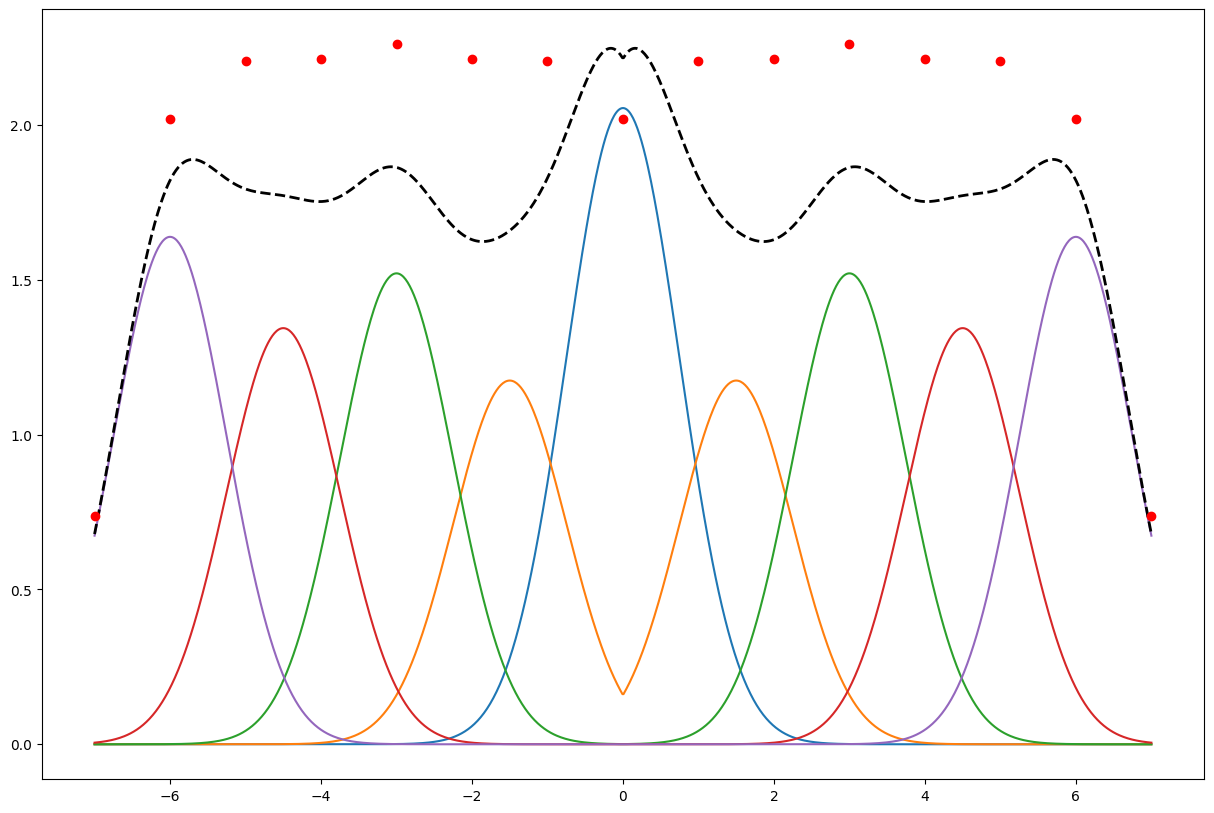

In [208]:
import torch
from matplotlib import pyplot as plt
# Define the rings 
rings = torch.tensor([0.0, 1.5, 3.0, 4.5, 6.0])
sigmas = torch.tensor([0.75, 0.75, 0.75, 0.75, 0.75])
weights = torch.tensor([1.1555, 0.6606, 0.8553, 0.7558, 0.9216])



def plot_rings1d(rings, sigmas, kernel_size=15):
    # Sample on 1D 
    a = (kernel_size - 1) // 2
    points = torch.linspace(-a, a, steps=1000)

    def evaluate_rings(points, rings, sigmas):
        # Evaluate the rings
        d = rings - torch.abs(points[:, None]) # Shape (1000, 5)
        y = torch.exp(-0.5 * d ** 2 / (sigmas ** 2)) / (sigmas ** 2)
        return y

    # Evaluate the rings
    y = evaluate_rings(points, rings, sigmas)
    print(y.shape)
    # plot rings
    for i in range(len(rings)):
        plt.plot(points, y[:, i] * weights[i])

    sum = (y * weights).sum(dim=1)
    #normalize = sum / sum.max()
    # plot sum 
    plt.plot(points, sum, 'k--', label="Sum", linewidth=2)
    # Plot the real px grid 
    px_values =evaluate_rings(torch.arange(-a, a + 1), rings, sigmas)
    px_values = px_values.sum(dim=1)
    print(px_values)
    #px_values = px_values / px_values.max()
    plt.scatter(torch.arange(-a, a + 1), px_values, color='red', zorder=5, label="Pixel Grid")


plt.figure(figsize=(15, 10))
plot_rings1d(rings, sigmas, kernel_size=15)
y.shape

Rings: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0] Sigmas: [0.005, 0.6, 0.6, 0.6, 0.6, 0.6, 0.6, 0.4]


TypeError: _sum() got an unexpected keyword argument 'dim'

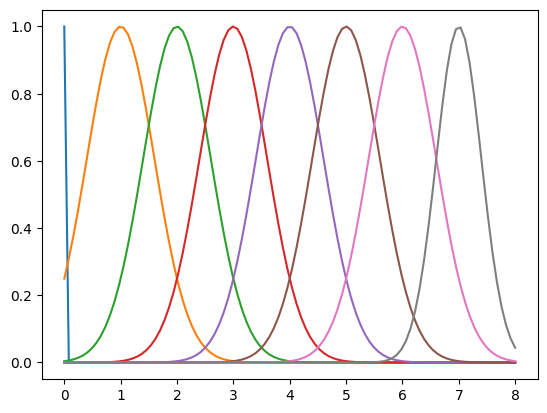

In [ ]:
import math
from e2cnn.kernels import KernelBasis
def e2cnn_default_rings_and_sigmas(kernel_size): 
    n_rings = math.ceil(kernel_size / 2)
    rings = torch.linspace(0, (kernel_size - 1) // 2, n_rings)
    rings = rings.tolist()
    sigma = [0.6] * (len(rings) - 1) + [0.4]
    for i, r in enumerate(rings):
        if r == 0.:
            sigma[i] = 0.005
    return rings, sigma


class GaussianRadialProfile(KernelBasis):
    
    def __init__(self, radii: List[float], sigma: Union[List[float], float]):
        r"""
        
        Basis for kernels defined over a radius in :math:`\R^+_0`.
        
        Each basis element is defined as a Gaussian function.
        Different basis elements are centered at different radii (``rings``) and can possibly be associated with
        different widths (``sigma``).
        
        More precisely, the following basis is implemented:
        
        .. math::
            
            \mathcal{B} = \left\{ b_i (r) :=  \exp \left( \frac{ \left( r - r_i \right)^2}{2 \sigma_i^2} \right) \right\}_i
        
        In order to build a complete basis of kernels, you should combine this basis with a basis which defines the
        angular profile through :class:`~e2cnn.kernels.PolarBasis`.
        
        
        Args:
            radii (list): centers of each basis element. They should be different and spread to cover all
                domain of interest
            sigma (list or float): widths of each element. Can potentially be different.
        
        
        """
        
        if isinstance(sigma, float):
            sigma = [sigma]*len(radii)
            
        assert len(radii) == len(sigma)
        assert isinstance(radii, list)
        
        for r in radii:
            assert r >= 0.
        
        for s in sigma:
            assert s > 0.
        
        super(GaussianRadialProfile, self).__init__(len(radii), (1, 1))

        self.radii = np.array(radii).reshape(1, 1, -1, 1)
        self.sigma = np.array(sigma).reshape(1, 1, -1, 1)
        
    def sample(self, radii: np.ndarray, out: np.ndarray = None) -> np.ndarray:
        r"""
        
        Sample the continuous basis elements on the discrete set of radii in ``radii``.
        Optionally, store the resulting multidimentional array in ``out``.

        ``radii`` must be an array of shape `(1, N)`, where `N` is the number of points.

        Args:
            radii (~numpy.ndarray): radii where to evaluate the basis elements
            out (~numpy.ndarray, optional): pre-existing array to use to store the output

        Returns:
            the sampled basis

        """
        assert len(radii.shape) == 2
        assert radii.shape[0] == 1
    
        if out is None:
            out = np.empty((self.shape[0], self.shape[1], self.dim, radii.shape[1]))
    
        assert out.shape == (self.shape[0], self.shape[1], self.dim, radii.shape[1])
    
        radii = radii.reshape(1, 1, 1, -1)
        
        d = (self.radii - radii)**2
        
        out = np.exp(-0.5*d/self.sigma**2, out=out)
        
        return out

    def __getitem__(self, r):
        assert r < self.dim
        return {"radius": self.radii[0, 0, r, 0], "sigma": self.sigma[0, 0, r, 0], "idx": r}

    def __eq__(self, other):
        if isinstance(other, GaussianRadialProfile):
            return np.allclose(self.radii, other.radii) and np.allclose(self.sigma, other.sigma)
        else:
            return False
    
    def __hash__(self):
        return hash(self.radii.tobytes()) + hash(self.sigma.tobytes())
    

rings, sigmas = e2cnn_default_rings_and_sigmas(15)
profile = GaussianRadialProfile(rings, sigmas)
print("Rings:", rings, "Sigmas:", sigmas)
points = np.linspace(0, 8, 100)
y = profile.sample(points.reshape(1, -1))[0,0] 
for i in range(len(rings)):
    plt.plot(points, y[i])


normalize = sum 
# plot sum 
plt.plot(points, normalize, 'k--', label="Sum", linewidth=2)
# Plot the real px grid 

In [ ]:
import numpy as np
from typing import List, Union




In [199]:
import torch

rings  = torch.tensor([0.0, 1.5, 3.0, 4.5, 6.0])
sigmas = torch.tensor([0.75, 0.75, 0.75, 0.75, 0.75])

# Domain of interest
r_min, r_max = -5.0, 5.0
r = torch.linspace(r_min, r_max, steps=2000)

# Build design matrix: G[k, i] = phi_i(r_k)
G = torch.exp(-0.5 * ((r[:, None] - rings[None, :]) / sigmas[None, :])**2)

y = torch.ones_like(r)  # target: uniform value 1

# Least squares solution restricted to [-6,6]
w, *_ = torch.linalg.lstsq(G, y)

print(w)


tensor([1.1555, 0.6606, 0.8553, 0.7558, 0.9216])


In [ ]:
def get_grid_coords(kernel_size: int, dilation: int = 1):
    
    actual_size = dilation * (kernel_size -1) + 1
    
    origin = actual_size / 2 - 0.5
    
    points = []
    
    for y in range(kernel_size):
        y *= dilation
        for x in range(kernel_size):
            x *= dilation
            p = (x - origin, -y + origin)
            points.append(p)
    
    points = np.array(points)
    assert points.shape == (kernel_size ** 2, 2), points.shape
    return points.T

filter = get_grid_coords(15)



(2, 225)

In [216]:
k = 15
ys = torch.arange(k) - (k - 1) / 2.0
xs = torch.arange(k) - (k - 1) / 2.0
yy, xx = torch.meshgrid(ys, xs, indexing="ij")
r =  torch.sqrt(yy ** 2 + xx ** 2)  # (k, k)
np.unique(r / r.max())


array([0.        , 0.10101525, 0.14285713, 0.20203051, 0.22587697,
       0.28571427, 0.30304575, 0.31943828, 0.36421567, 0.40406102,
       0.41649655, 0.4285714 , 0.45175394, 0.5050763 , 0.5150787 ,
       0.54398376, 0.57142854, 0.58901507, 0.6060915 , 0.6144518 ,
       0.63887656, 0.6468132 , 0.6776309 , 0.70710677, 0.7142857 ,
       0.72843134, 0.73540217, 0.7693093 , 0.7889544 , 0.814411  ,
       0.8571428 , 0.8689661 , 0.9313146 , 1.        ], dtype=float32)